# Hockey Career Trajectory Predictor — Evaluation

Analysis of the walk-forward backtest outputs (1990-91 → 2023-24).
Run `python -m src.backtest` first to produce `data/output/*`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('../data/output')
vet_preds = pd.read_parquet(OUT / 'veteran_predictions.parquet')
vet_seasons = pd.read_csv(OUT / 'veteran_season_metrics.csv')
rook_preds = pd.read_parquet(OUT / 'rookie_predictions.parquet')
rook_classes = pd.read_csv(OUT / 'rookie_class_metrics.csv')
veterans = pd.read_parquet(OUT / 'veteran_features.parquet')
rookies = pd.read_parquet(OUT / 'rookie_features.parquet')
plt.rcParams['figure.figsize'] = (11, 4)

## 1. Veteran model: accuracy over time

Success metric (PRD): **MAE < 0.08 PPG** league-wide, and beating the 'last season's PPG' baseline.

Seasons evaluated : 33
Mean MAE (model)  : 0.1289
Mean MAE (baseline): 0.1543
Mean R2           : 0.628
Directional acc.  : 68.2%


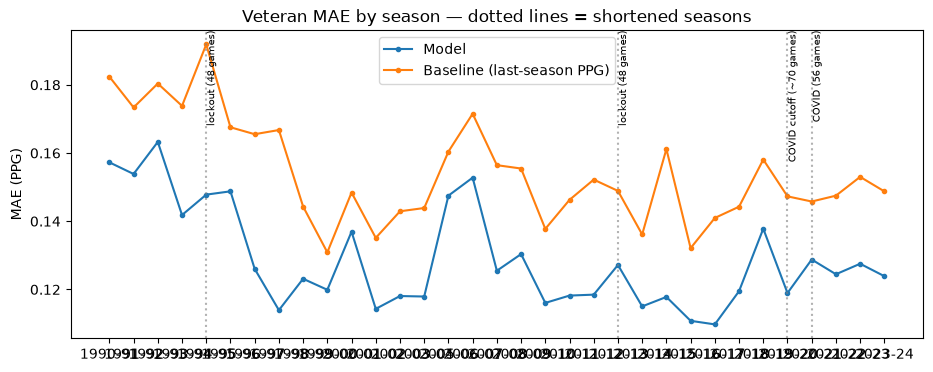

In [2]:
m = vet_seasons.dropna(subset=['mae'])
print(f"Seasons evaluated : {len(m)}")
print(f"Mean MAE (model)  : {m['mae'].mean():.4f}")
print(f"Mean MAE (baseline): {m['mae_baseline'].mean():.4f}")
print(f"Mean R2           : {m['r2'].mean():.3f}")
print(f"Directional acc.  : {m['directional_accuracy'].mean():.1%}")

fig, ax = plt.subplots()
ax.plot(m['season'], m['mae'], marker='o', ms=3, label='Model')
ax.plot(m['season'], m['mae_baseline'], marker='o', ms=3, label='Baseline (last-season PPG)')
for _, r in m[m['shortened'].fillna('') != ''].iterrows():
    ax.axvline(r['season'], ls=':', color='gray', alpha=.6)
    ax.annotate(r['shortened'], (r['season'], ax.get_ylim()[1]), rotation=90, fontsize=7, va='top')
ax.set_ylabel('MAE (PPG)'); ax.legend(); ax.set_title('Veteran MAE by season — dotted lines = shortened seasons')
plt.show()

In [3]:
# Biggest over/under-performers across the whole backtest
ev = vet_preds[vet_preds['eval_ok']].dropna(subset=['ppg_next']).copy()
ev['err'] = ev['ppg_next'] - ev['pred_ppg']
from src.constants import season_label
ev['season'] = ev['pred_season'].map(season_label)
cols = ['skaterFullName', 'season', 'ppg_last1', 'pred_ppg', 'ppg_next', 'err']
display(ev.nlargest(10, 'err')[cols])
display(ev.nsmallest(10, 'err')[cols])

,skaterFullName,season,ppg_last1,pred_ppg,ppg_next,err
420,Mark Recchi,1990-91,0.133333,0.291228,1.448718,1.157490
382,Adam Oates,1990-91,1.130435,0.792291,1.885246,1.092955
1411,Mario Lemieux,1992-93,1.730769,1.732434,2.666667,0.934233
22486,Tage Thompson,2022-23,0.368421,0.293736,1.205128,0.911393
12060,Mike Green,2008-09,0.171429,0.210722,1.073529,0.862808
9800,Jonathan Cheechoo,2005-06,0.242424,0.286833,1.134146,0.847313
9967,Jason Spezza,2005-06,0.636364,0.514478,1.323529,0.809051
3504,Ziggy Palffy,1995-96,0.000000,0.279771,1.074074,0.794303
21962,Erik Karlsson,2022-23,0.423077,0.449831,1.231707,0.781877
21787,Jason Robertson,2021-22,0.333333,0.286967,1.067568,0.780600


,skaterFullName,season,ppg_last1,pred_ppg,ppg_next,err
4223,Curtis Brown,1996-97,2.000000,1.027186,0.250000,-0.777186
2055,Eddie Olczyk,1993-94,1.015625,0.918508,0.216216,-0.702292
14073,Mike Green,2011-12,1.013333,0.873677,0.218750,-0.654927
58,Jimmy Carson,1990-91,1.250000,1.366315,0.718750,-0.647565
39,Rob Brown,1990-91,1.691176,1.459120,0.840580,-0.618540
20453,Evgenii Dadonov,2020-21,0.853659,0.968416,0.363636,-0.604780
2879,Dixon Ward,1994-95,0.742857,0.726558,0.136364,-0.590194
159,Gerard Gallant,1990-91,1.223684,1.162306,0.577778,-0.584528
2772,Steve Yzerman,1994-95,1.630952,1.367922,0.808511,-0.559411
449,Denis Savard,1990-91,1.413793,1.388889,0.842857,-0.546032


## 2. Rookie model: draft-class walk-forward

Success metric (PRD): **Spearman ρ > 0.55** between predicted and actual rookie PPG.

Classes evaluated : 31
Mean MAE          : 0.1327
Mean Spearman rho : 0.354


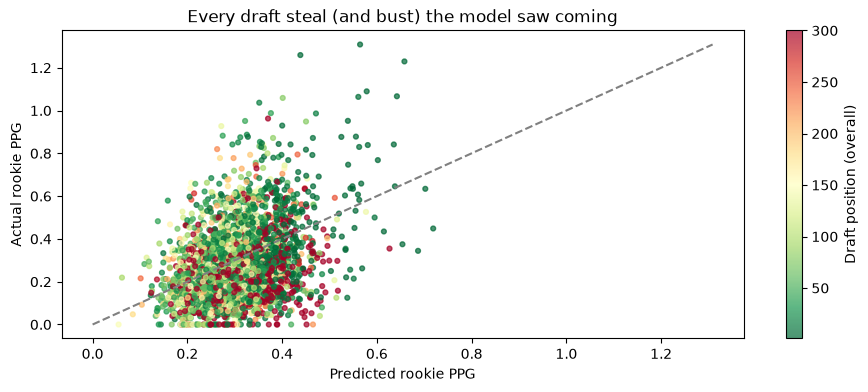

In [4]:
print(f"Classes evaluated : {len(rook_classes)}")
print(f"Mean MAE          : {rook_classes['mae'].mean():.4f}")
print(f"Mean Spearman rho : {rook_classes['spearman'].mean():.3f}")

fig, ax = plt.subplots()
sc = ax.scatter(rook_preds['pred_ppg'], rook_preds['ppg_rookie'],
                c=rook_preds['draft_ovr'], cmap='RdYlGn_r', s=12, alpha=.7)
lim = max(rook_preds['pred_ppg'].max(), rook_preds['ppg_rookie'].max())
ax.plot([0, lim], [0, lim], ls='--', color='gray')
plt.colorbar(sc, label='Draft position (overall)')
ax.set_xlabel('Predicted rookie PPG'); ax.set_ylabel('Actual rookie PPG')
ax.set_title('Every draft steal (and bust) the model saw coming')
plt.show()

In [5]:
# Steals: predicted well above draft-slot expectation AND delivered
rp = rook_preds.copy()
rp['draft_decile'] = pd.qcut(rp['draft_ovr'], 10, labels=False, duplicates='drop')
rp['expectation'] = rp.groupby('draft_decile')['ppg_rookie'].transform('mean')  # empirical draft-slot expectation
rp['steal_score'] = rp['pred_ppg'] - rp['expectation']
rp['delivered'] = rp['ppg_rookie'] - rp['expectation']
rp['season'] = rp['rookie_season'].map(season_label)
cols = ['skaterFullName', 'season', 'draft_ovr', 'pred_ppg', 'ppg_rookie', 'steal_score']
print('Top steals (model high, draft low, player delivered):')
display(rp[rp['delivered'] > 0].nlargest(15, 'steal_score')[cols])
print('Top busts (top-10 pick, lowest actual):')
display(rp[rp['draft_ovr'] <= 10].nsmallest(15, 'ppg_rookie')[cols])

Top steals (model high, draft low, player delivered):


,skaterFullName,season,draft_ovr,pred_ppg,ppg_rookie,steal_score
86,John Conroy,1991-92,300.0,0.626694,0.354839,0.380827
1570,James van Riemsdyk,2009-10,2.0,0.718867,0.448718,0.324950
158,Andrei Lomakin,1991-92,138.0,0.576943,0.526316,0.309638
2555,Nico Hischier,2017-18,1.0,0.702197,0.634146,0.308279
12,Michael McNeil,1990-91,300.0,0.516546,0.297297,0.270679
355,German Titov,1993-94,252.0,0.511205,0.592105,0.265337
90,Eric Lindros,1992-93,1.0,0.658149,1.229508,0.264232
274,Jim Montgomery,1993-94,300.0,0.499488,0.298507,0.253620
11,Jeff Lazaro,1990-91,300.0,0.495745,0.367347,0.249877
87,Chris Lindberg,1991-92,300.0,0.495130,0.411765,0.249262


Top busts (top-10 pick, lowest actual):


,skaterFullName,season,draft_ovr,pred_ppg,ppg_rookie,steal_score
1280,Alexandre Picard,2005-06,8.0,0.348867,0.000000,-0.045051
1618,Keaton Ellerby,2009-10,10.0,0.256674,0.000000,-0.137244
1892,Nino Niederreiter,2011-12,5.0,0.331778,0.018182,-0.062140
557,Johnathan Aitken,2003-04,8.0,0.173402,0.024390,-0.220516
96,Alek Stojanov,1995-96,7.0,0.364270,0.029412,-0.029648
558,Ruslan Salei,1996-97,9.0,0.320523,0.033333,-0.073394
2039,Griffin Reinhart,2015-16,4.0,0.247804,0.034483,-0.146113
1003,Mike Komisarek,2002-03,7.0,0.187818,0.047619,-0.206100
721,Rico Fata,1998-99,6.0,0.348077,0.050000,-0.045840
2801,Marco Rossi,2022-23,9.0,0.398340,0.052632,0.004422


## 3. Interpretability: SHAP on the final veteran model

PRD narrative hook: *the aging curve is real* — `age`/`age_sq` should rank among the most important features.

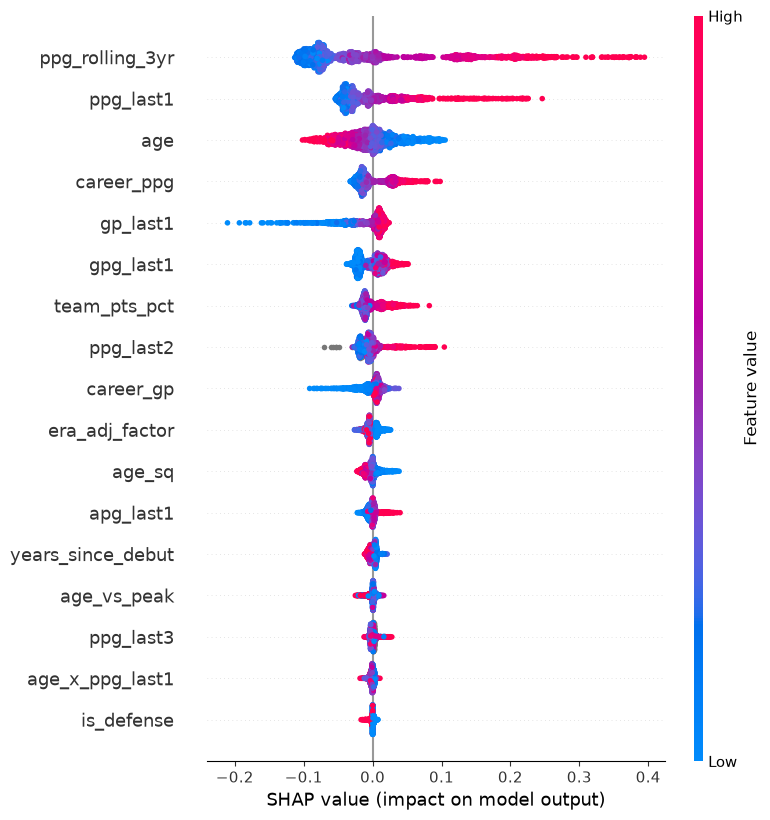

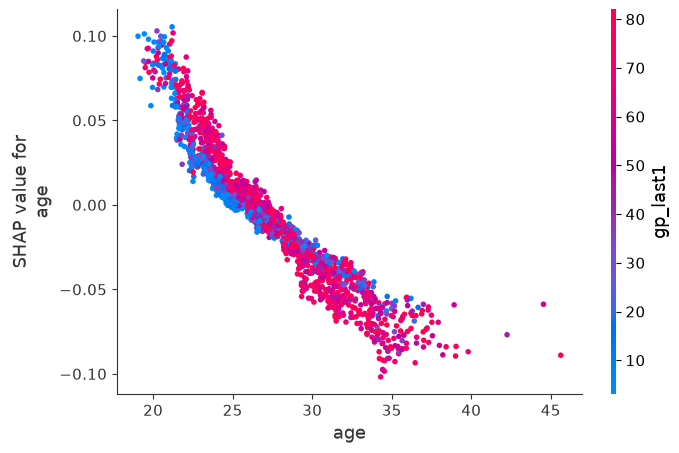

In [6]:
import shap
from src.features import VETERAN_FEATURES
from src.model import train_model
from src.constants import season_window, FIRST_BACKTEST_SEASON, LAST_BACKTEST_SEASON

final_window = season_window(FIRST_BACKTEST_SEASON, LAST_BACKTEST_SEASON)[-6:-1]
train = veterans[veterans['next_season_actual'].isin(final_window)]
trained = train_model(train, VETERAN_FEATURES, 'ppg_next', order_col='next_season_actual')

sample = train[VETERAN_FEATURES].sample(min(2000, len(train)), random_state=42)
explainer = shap.TreeExplainer(trained.model)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=False)
plt.show()
shap.dependence_plot('age', shap_values, sample, show=False)
plt.show()

## Findings

See `WRITEUP.md` for the full narrative.